# ToDo

# Подготовка

## Настройка графики

In [1]:
#windows.options(height=5.4, width=7)
oldpar = par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE);

require(vcd, quietly = TRUE, warn.conflicts = FALSE);
require(coin, quietly = TRUE, warn.conflicts = FALSE);          # independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE);     # HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE);      # kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE);       # for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE);     # numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE);
require(lattice, quietly = TRUE, warn.conflicts = FALSE);
require(mosaic, quietly = TRUE, warn.conflicts = FALSE);
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE);
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE);        # ggqqplot
#require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
#require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE);                            # flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE);    # ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE);        # ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE);       # ggparcoord


require(rstatix, quietly = TRUE);                               # identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidyr, quietly = TRUE, warn.conflicts = FALSE);
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE);
#require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE);
require(repr, quietly = TRUE, warn.conflicts = FALSE);

require(knitr, quietly = TRUE, warn.conflicts = FALSE);        # Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
#sessionInfo()
#options(encoding = "UTF-8")
lor = read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet="данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor = lor %>% 
    dplyr::select("id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                  ) %>%
    filter(локация != "полип") %>%
    filter(группа != "КГ")

# Get data for "КГ1"
og_data <- lor %>% 
    filter(группа == "КГ1")

# Create duplicates for other periods
og_t1 <- og_data %>%
    mutate(этап = "6-7 сутки")

og_t2 <- og_data %>%
    mutate(этап = "1-3 мес.")

og_t3 <- og_data %>%
    mutate(этап = "1 год")

# Combine original data with the duplicated data
lor <- lor %>%
    bind_rows(og_t1, og_t2, og_t3)

lor = as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа = factor(lor$группа, c("ОГ", "КГ1"))
lor$"локация" = factor(lor$"локация")
lor$"этап" = factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
    group_by(id, группа, локация, этап) %>%
    summarise(
        across(c(
                "круглоклеточная воспалительная инфильтрация", 
                  "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия", 
                  "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
                ),
            ~ median(.x, na.rm = TRUE)
        ),
        .groups = "drop"
        # mean_value = mean(measurement_value, na.rm = TRUE),
        # median_value = median(measurement_value, na.rm = TRUE),
        # sd_value = sd(measurement_value, na.rm = TRUE),
        # min_value = min(measurement_value, na.rm = TRUE),
        # max_value = max(measurement_value, na.rm = TRUE)
    ) %>%
    arrange(id) 
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable = 'группа'

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname = "круглоклеточная воспалительная инфильтрация"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

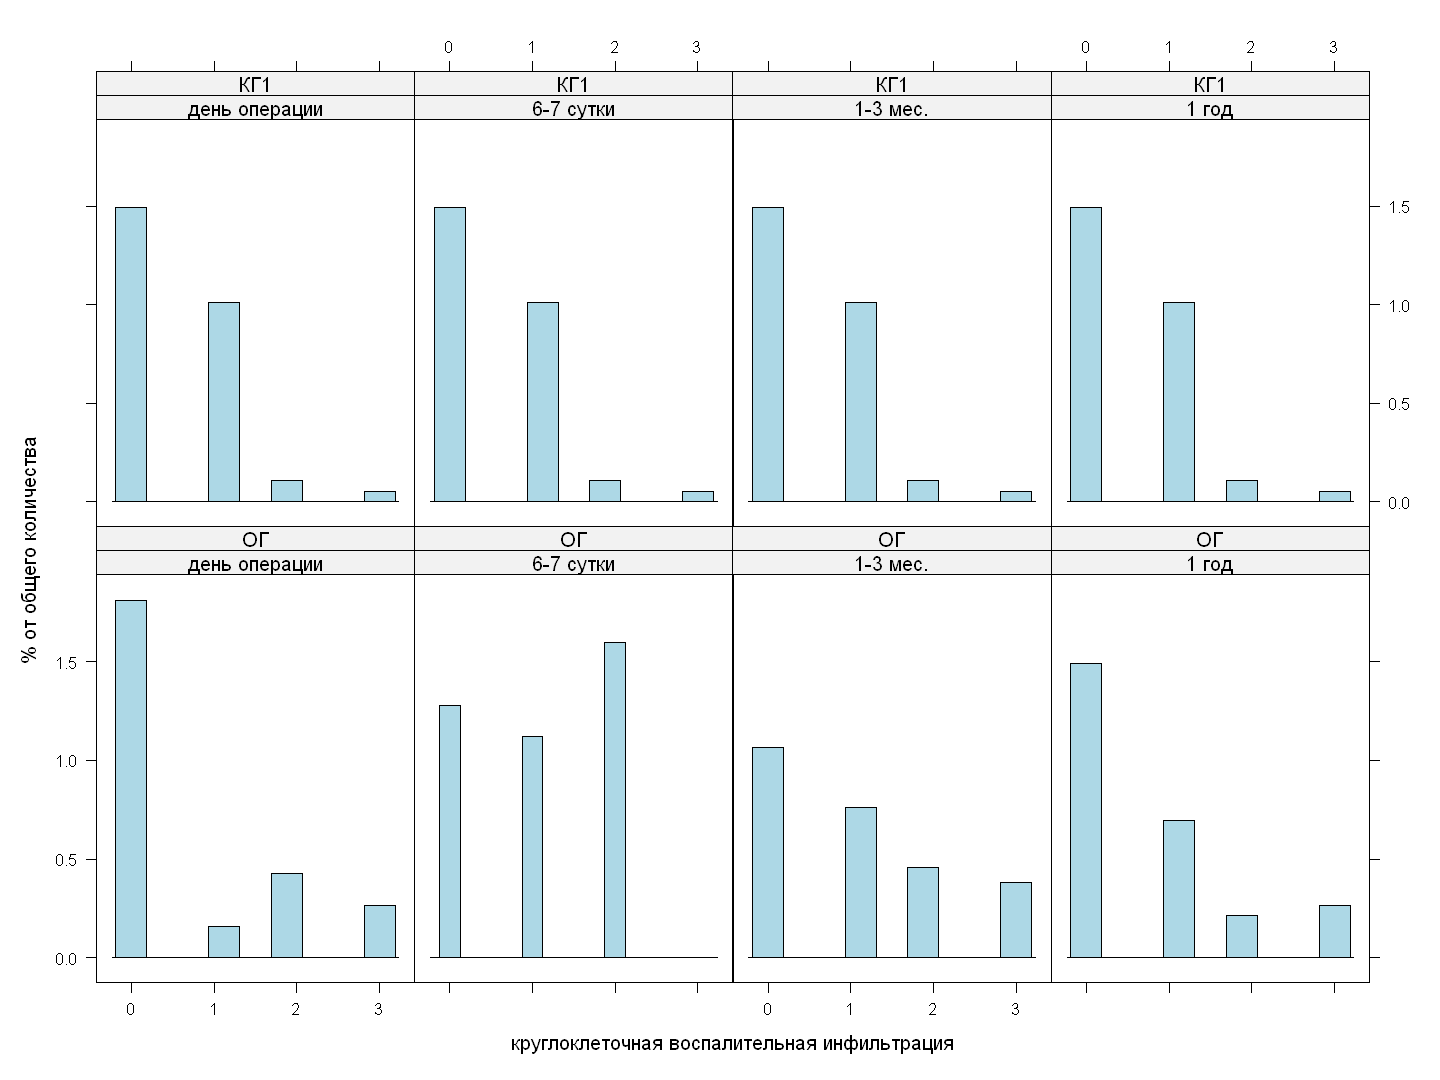

In [10]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ1: 1-3 мес.      0.520000 0.6773297 1.00  0   0   0 1.00    3     50
КГ1: 1 год         0.520000 0.6773297 1.00  0   0   0 1.00    3     50
КГ1: 6-7 сутки     0.520000 0.6773297 1.00  0   0   0 1.00    3     50
КГ1: день операции 0.520000 0.6773297 1.00  0   0   0 1.00    3     50
ОГ: 1-3 мес.       1.057143 1.0831017 2.00  0   0   1 2.00    3     35
ОГ: 1 год          0.720000 0.9905678 1.00  0   0   0 1.00    3     50
ОГ: 6-7 сутки      1.080000 0.8621678 2.00  0   0   1 2.00    2     25
ОГ: день операции  0.680000 1.0774119 1.75  0   0   0 1.75    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,1.75,3,0.680000,1.0774119,50,0
КГ1.день операции,0,0,0,1.00,3,0.520000,0.6773297,50,0
ОГ.6-7 сутки,0,0,1,2.00,2,1.080000,0.8621678,25,0
КГ1.6-7 сутки,0,0,0,1.00,3,0.520000,0.6773297,50,0
ОГ.1-3 мес.,0,0,1,2.00,3,1.057143,1.0831017,35,0
КГ1.1-3 мес.,0,0,0,1.00,3,0.520000,0.6773297,50,0
ОГ.1 год,0,0,0,1.00,3,0.720000,0.9905678,50,0
КГ1.1 год,0,0,0,1.00,3,0.520000,0.6773297,50,0


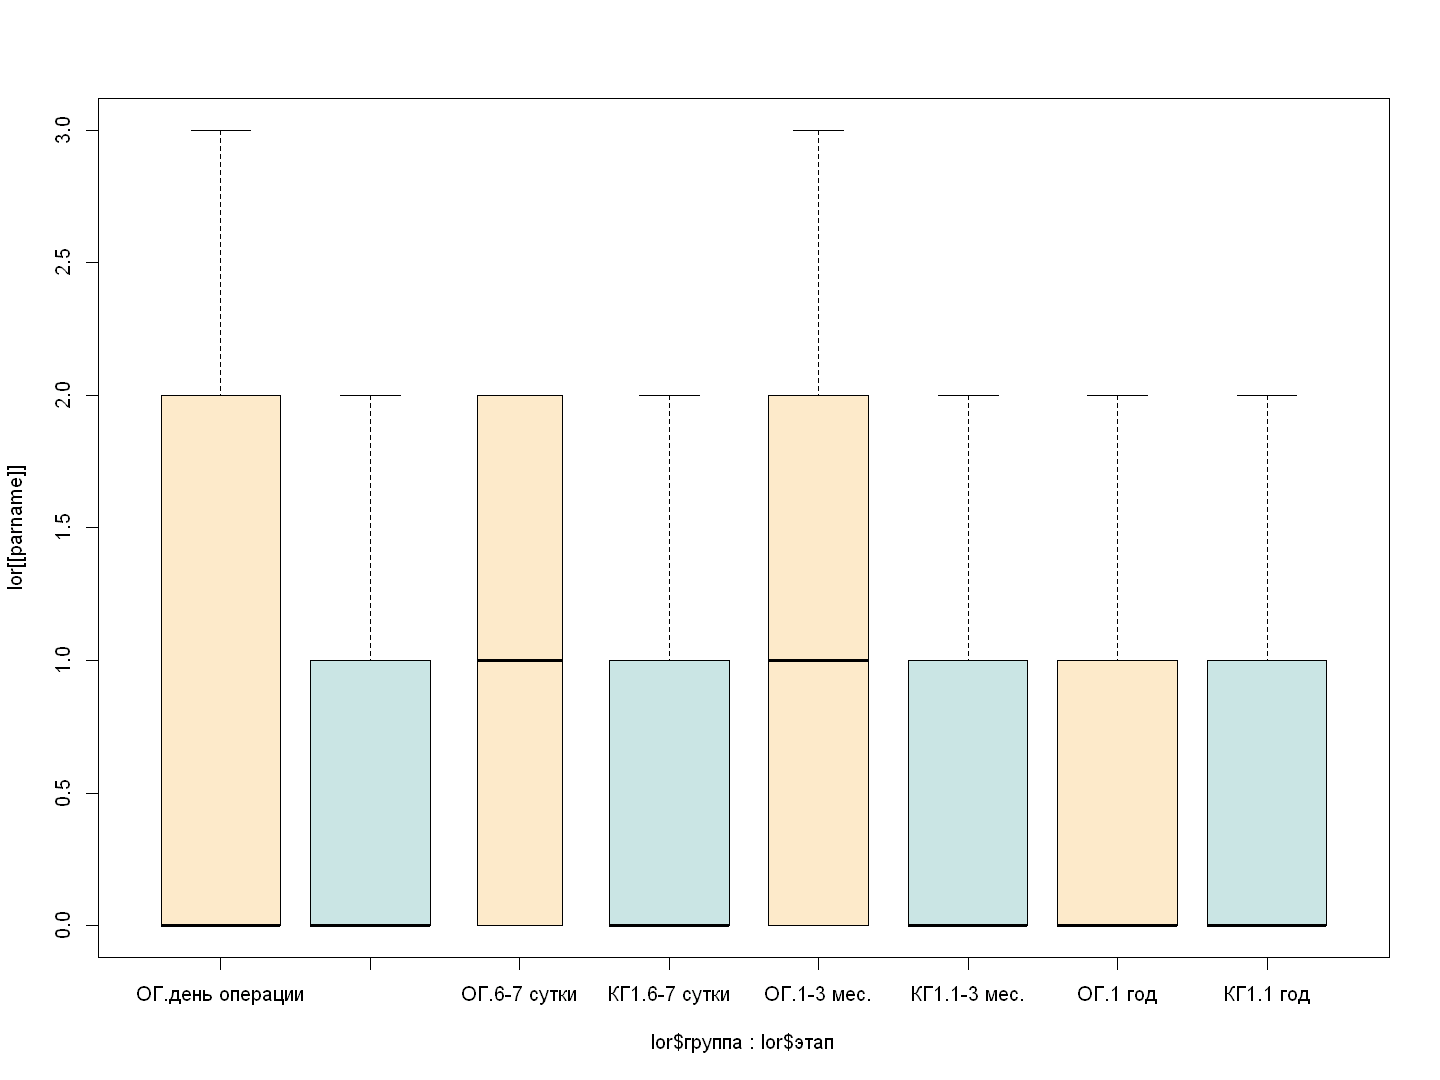

In [12]:
parname = sub("\\..*", "", parname)
# # beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
# #          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [13]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1220, p-value = 0.8143
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -0.23883, p-value = 0.8112
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 854.5, p-value = 0.005081
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.808, p-value = 0.004986
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1106.5, p-value = 0.02429
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.2574, p-

## бокаловидные клетки

### Общее

In [14]:
parname = "бокаловидные клетки"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [15]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [16]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: 1 год         0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: 6-7 сутки     0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: день операции 0.3800000 0.6667007   1  0   0   0   1    2     50
ОГ: 1-3 мес.       0.7714286 1.0025178   1  0   0   0   1    3     35
ОГ: 1 год          0.4400000 0.9722685   0  0   0   0   0    3     50
ОГ: 6-7 сутки      0.0000000 0.0000000   0  0   0   0   0    0     25
ОГ: день операции  0.0800000 0.3404679   0  0   0   0   0    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0,2,0.0800000,0.3404679,50,0
КГ1.день операции,0,0,0,1,2,0.3800000,0.6667007,50,0
ОГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,25,0
КГ1.6-7 сутки,0,0,0,1,2,0.3800000,0.6667007,50,0
ОГ.1-3 мес.,0,0,0,1,3,0.7714286,1.0025178,35,0
КГ1.1-3 мес.,0,0,0,1,2,0.3800000,0.6667007,50,0
ОГ.1 год,0,0,0,0,3,0.4400000,0.9722685,50,0
КГ1.1 год,0,0,0,1,2,0.3800000,0.6667007,50,0


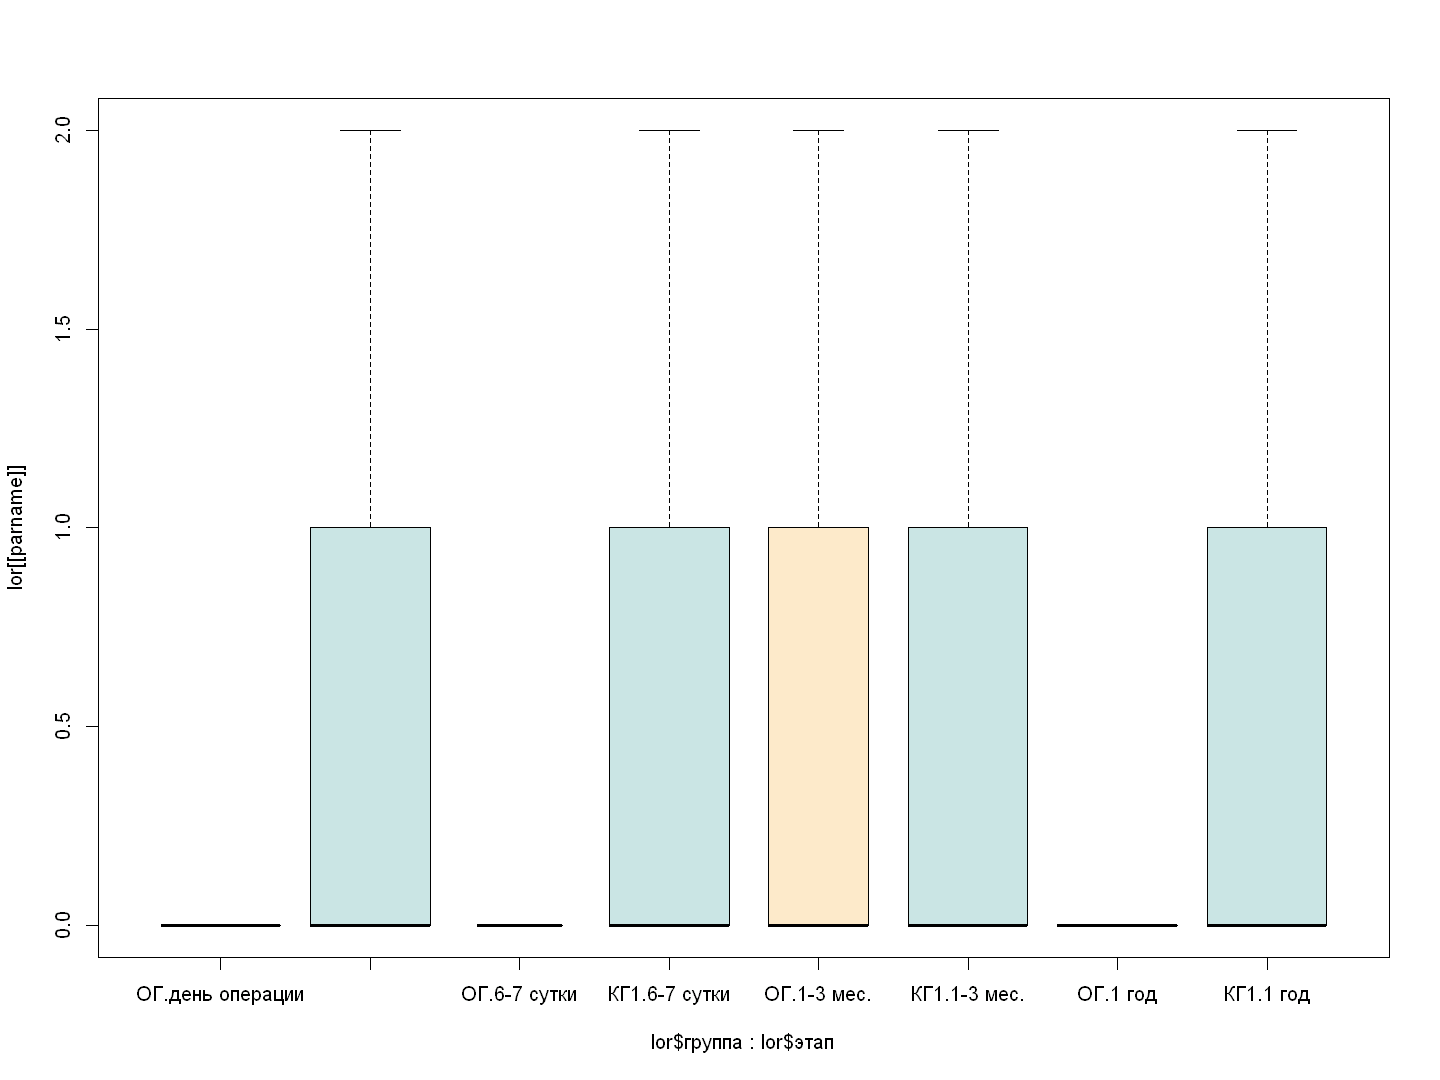

In [17]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [18]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 974.5, p-value = 0.003706
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -2.9075, p-value = 0.003644
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 450, p-value = 0.003833
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -2.8998, p-value = 0.003733
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1053.5, p-value = 0.06096
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 1.8791

## отек

### Общее

In [19]:
parname = "отек"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

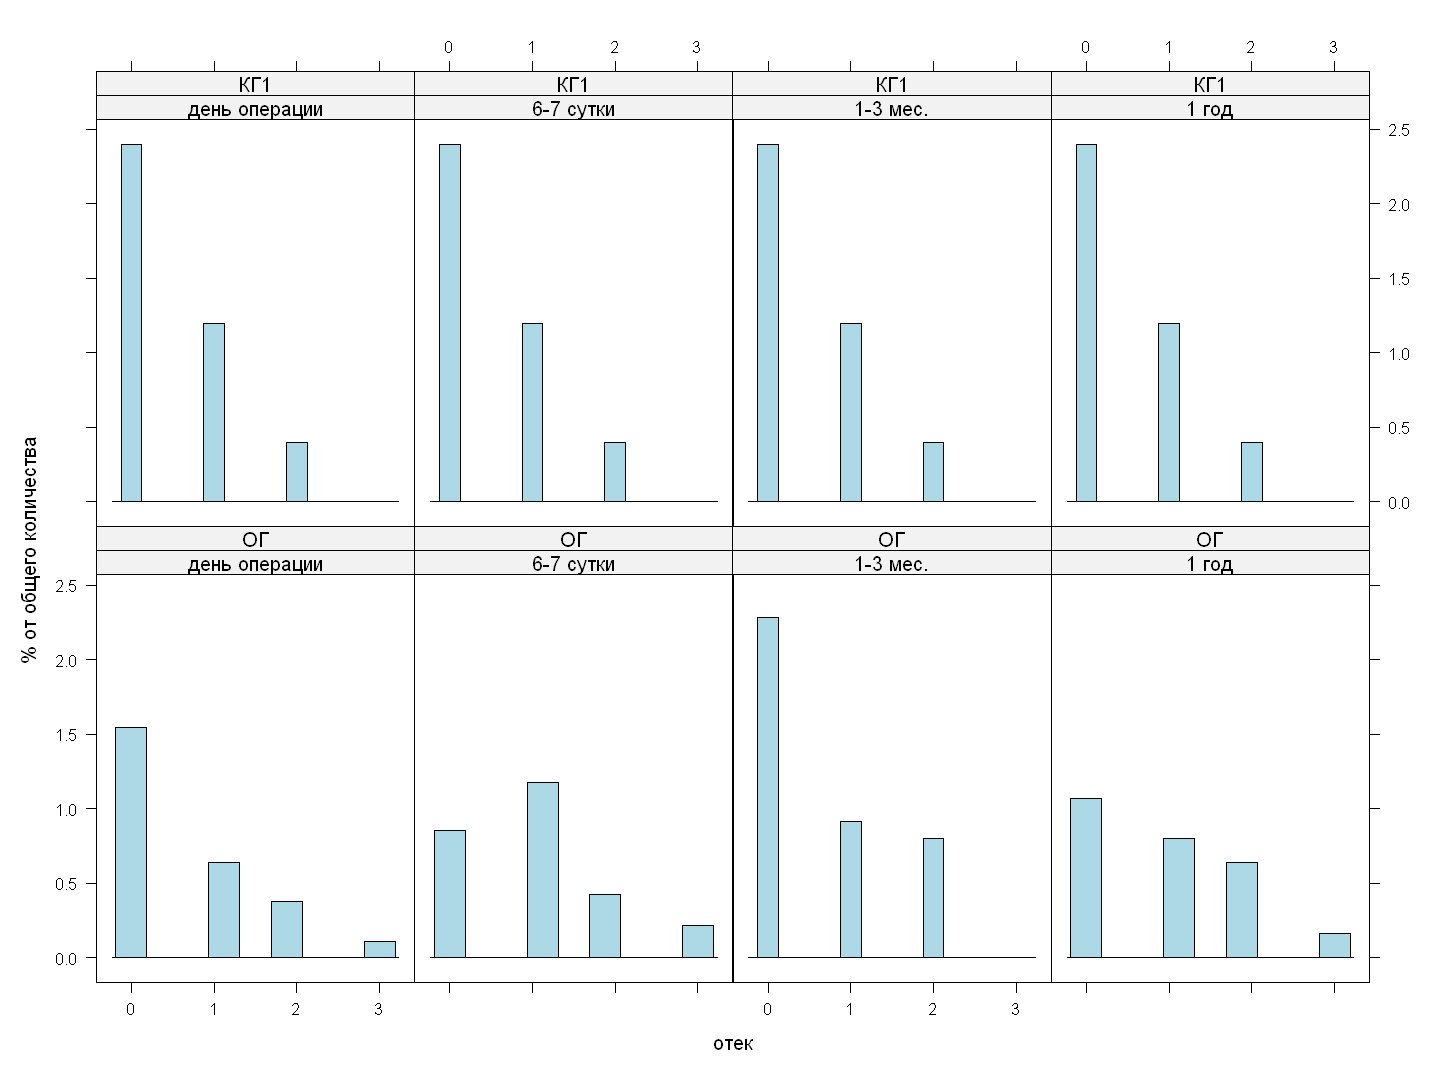

In [20]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [21]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: 1 год         0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: 6-7 сутки     0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: день операции 0.5000000 0.6776309   1  0   0   0   1    2     50
ОГ: 1-3 мес.       0.6285714 0.8075276   1  0   0   0   1    2     35
ОГ: 1 год          0.9600000 0.9467452   2  0   0   1   2    3     50
ОГ: 6-7 сутки      1.0000000 0.9128709   1  0   0   1   1    3     25
ОГ: день операции  0.6400000 0.8750510   1  0   0   0   1    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,1,3,0.6400000,0.8750510,50,0
КГ1.день операции,0,0,0,1,2,0.5000000,0.6776309,50,0
ОГ.6-7 сутки,0,0,1,1,3,1.0000000,0.9128709,25,0
КГ1.6-7 сутки,0,0,0,1,2,0.5000000,0.6776309,50,0
ОГ.1-3 мес.,0,0,0,1,2,0.6285714,0.8075276,35,0
КГ1.1-3 мес.,0,0,0,1,2,0.5000000,0.6776309,50,0
ОГ.1 год,0,0,1,2,3,0.9600000,0.9467452,50,0
КГ1.1 год,0,0,0,1,2,0.5000000,0.6776309,50,0


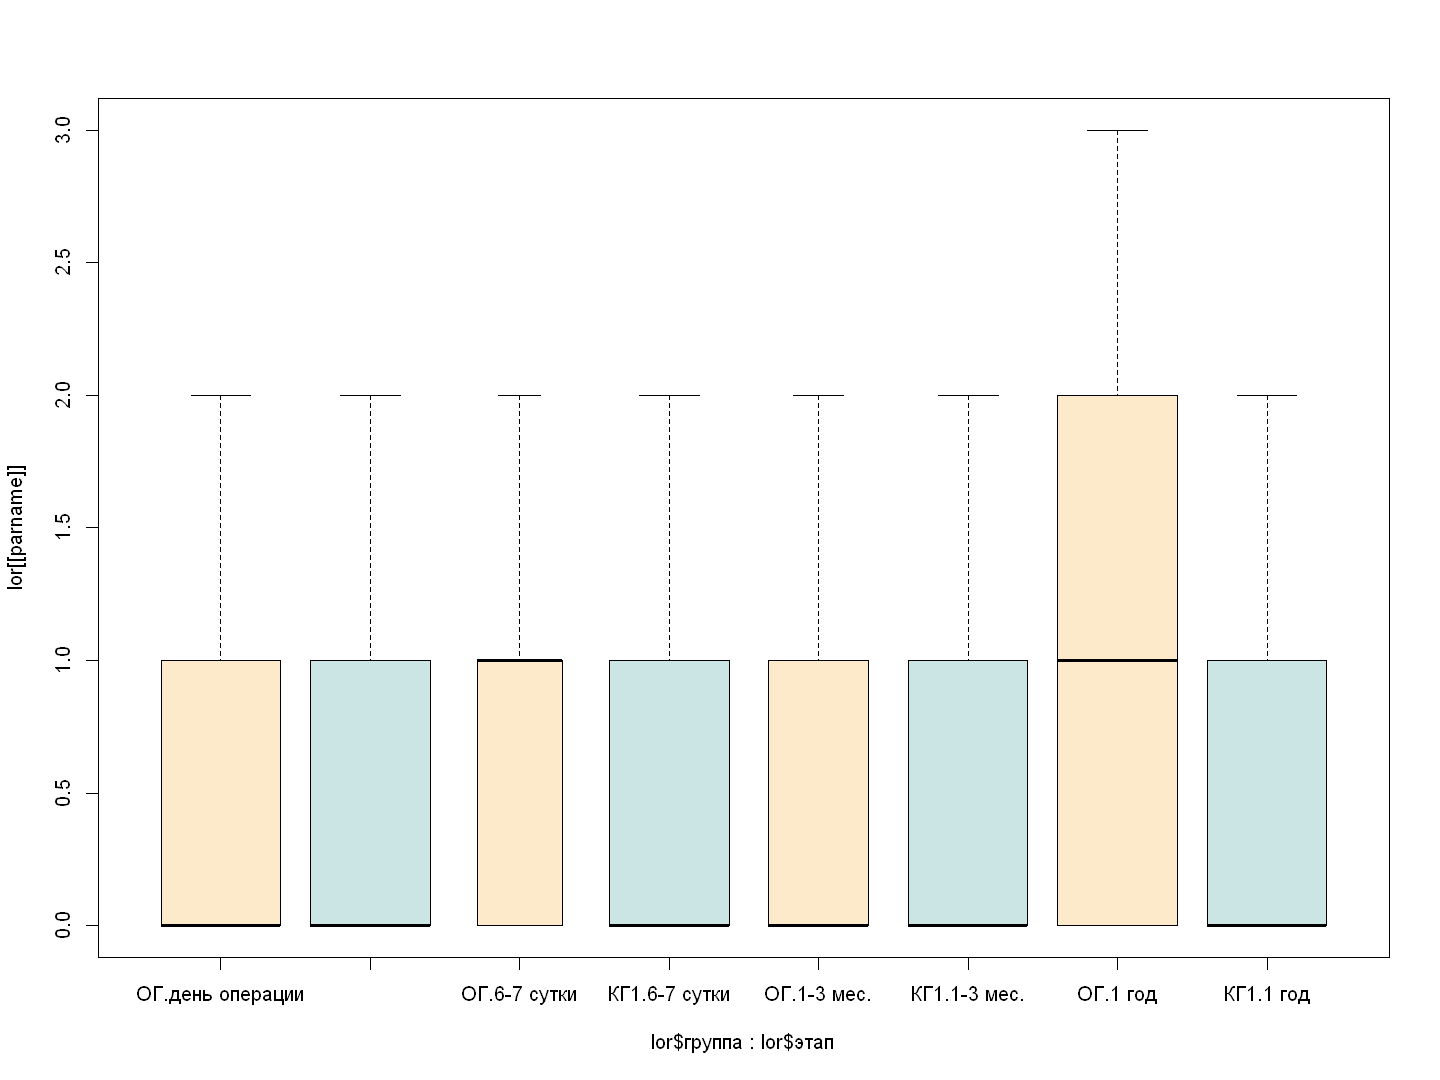

In [22]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [23]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1317.5, p-value = 0.5994
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.52917, p-value = 0.5967
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 822.5, p-value = 0.01488
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.4413, p-value = 0.01463
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 932.5, p-value = 0.5629
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.58363, p-v

## реснички эпителия

### Общее

In [24]:
parname = "реснички эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

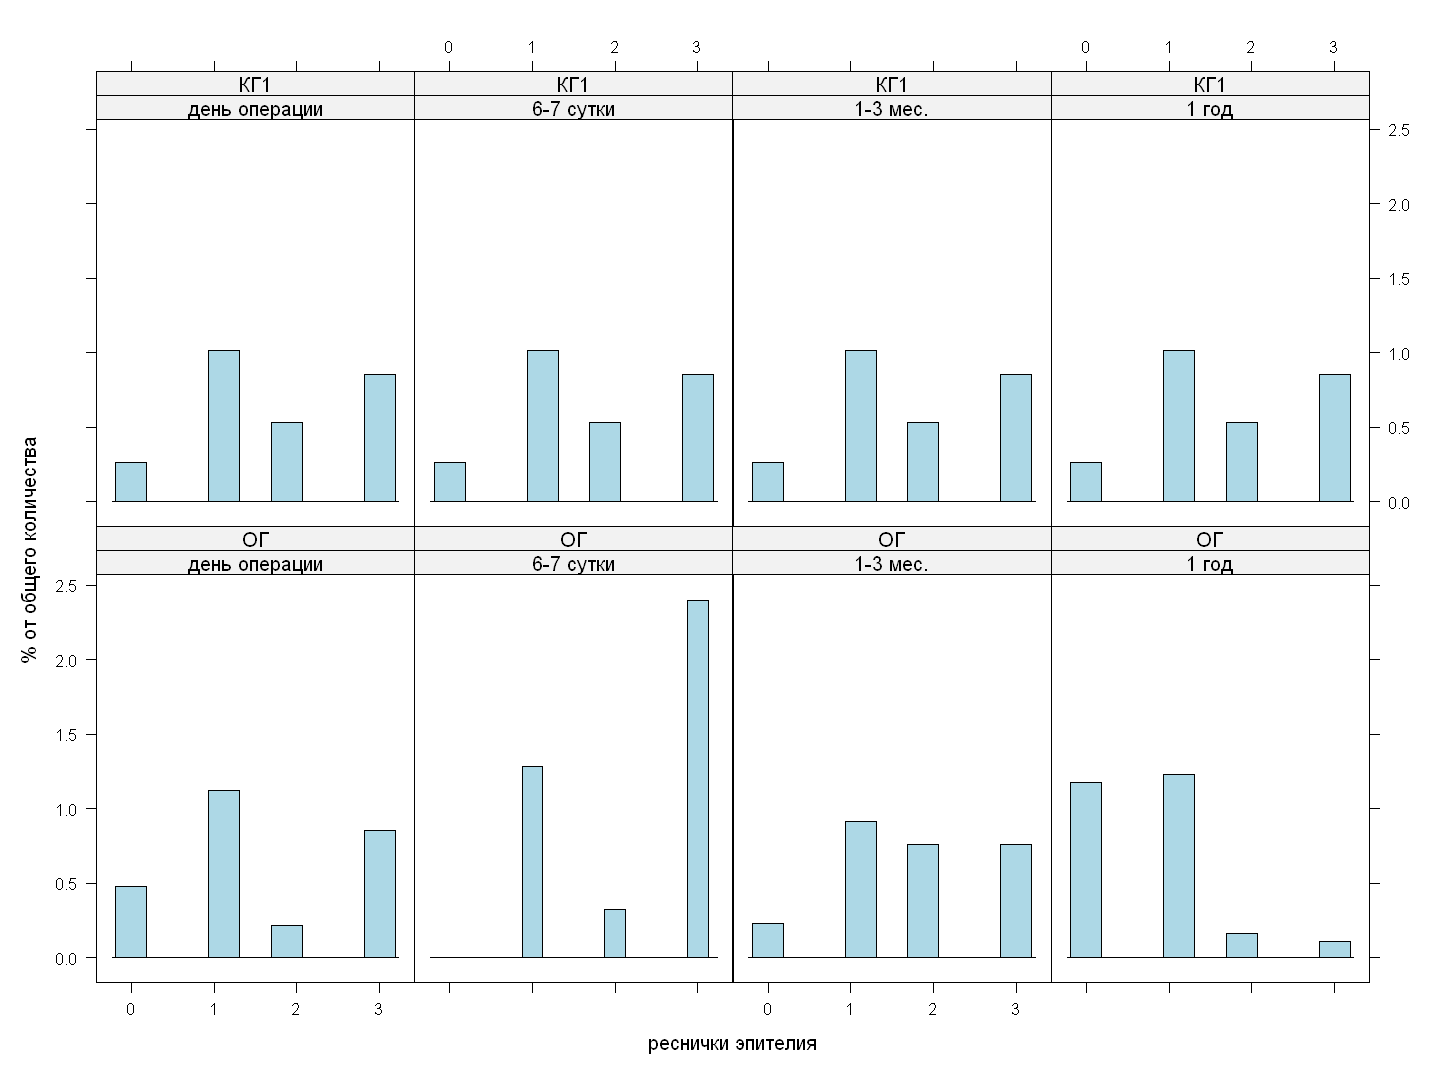

In [25]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [26]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      1.740000 1.0263866   2  0   1   2   3    3     50
КГ1: 1 год         1.740000 1.0263866   2  0   1   2   3    3     50
КГ1: 6-7 сутки     1.740000 1.0263866   2  0   1   2   3    3     50
КГ1: день операции 1.740000 1.0263866   2  0   1   2   3    3     50
ОГ: 1-3 мес.       1.771429 0.9727376   2  0   1   2   3    3     35
ОГ: 1 год          0.700000 0.7626484   1  0   0   1   1    3     50
ОГ: 6-7 сутки      2.280000 0.9363048   2  1   1   3   3    3     25
ОГ: день операции  1.540000 1.1286618   2  0   1   1   3    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1,1,3,3,1.540000,1.1286618,50,0
КГ1.день операции,0,1,2,3,3,1.740000,1.0263866,50,0
ОГ.6-7 сутки,1,1,3,3,3,2.280000,0.9363048,25,0
КГ1.6-7 сутки,0,1,2,3,3,1.740000,1.0263866,50,0
ОГ.1-3 мес.,0,1,2,3,3,1.771429,0.9727376,35,0
КГ1.1-3 мес.,0,1,2,3,3,1.740000,1.0263866,50,0
ОГ.1 год,0,0,1,1,3,0.700000,0.7626484,50,0
КГ1.1 год,0,1,2,3,3,1.740000,1.0263866,50,0


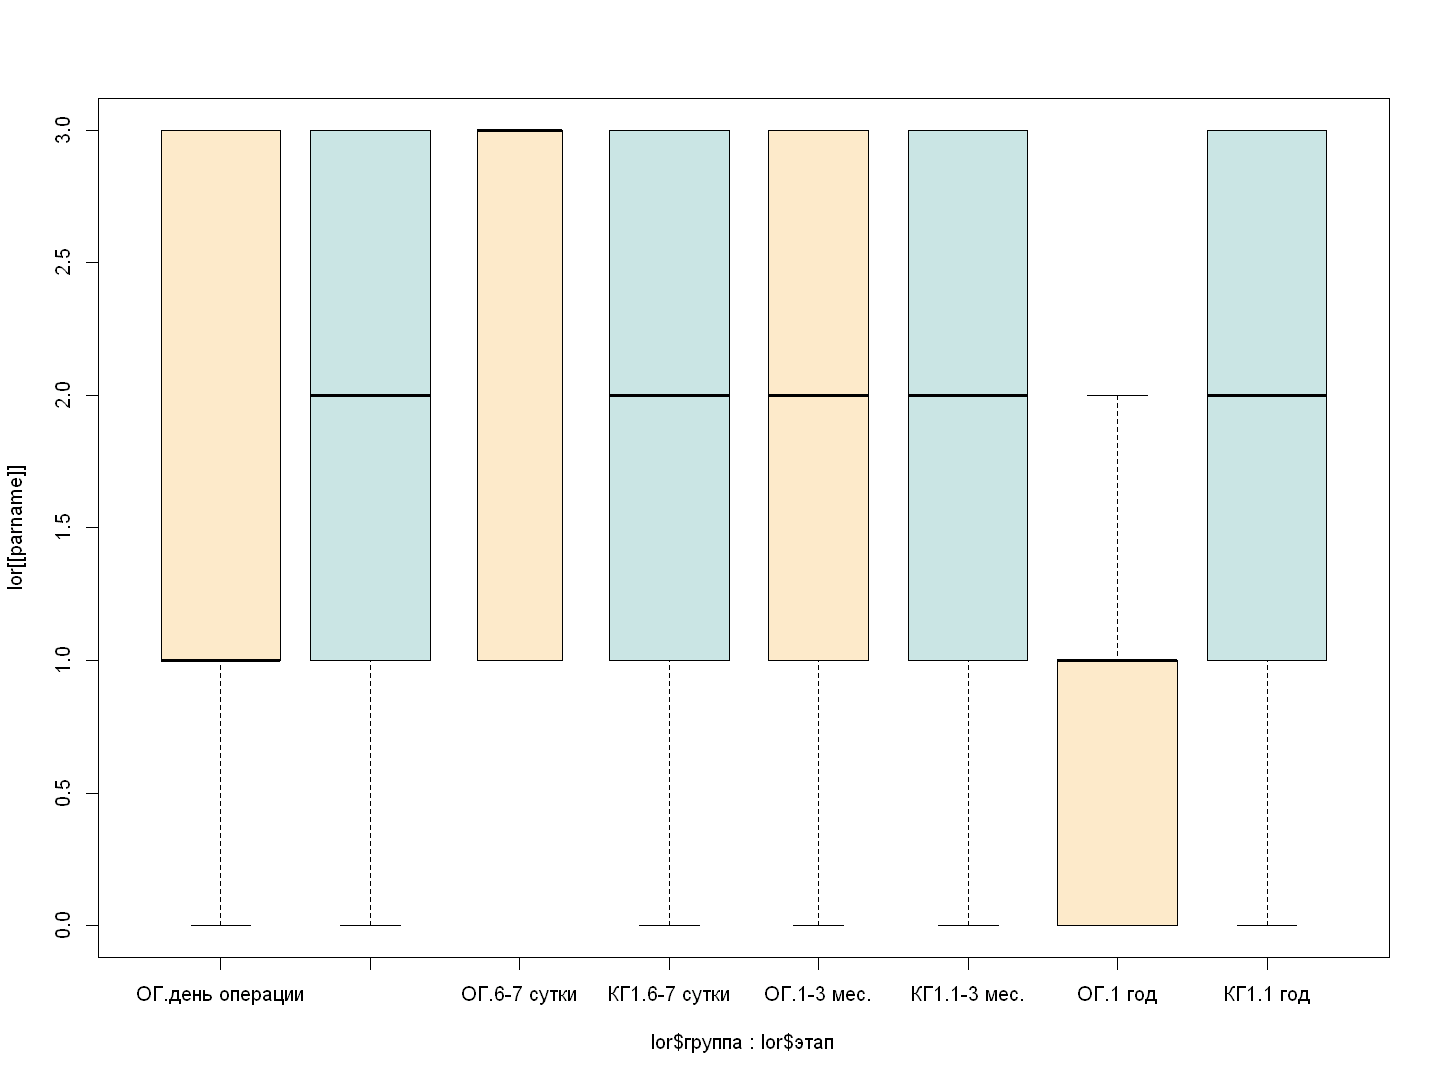

In [27]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [28]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1115, p-value = 0.3278
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -0.98219, p-value = 0.326
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 804, p-value = 0.03232
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.1464, p-value = 0.03184
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 891.5, p-value = 0.8809
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.15452, p-value

## фиброз

### Общее

In [29]:
parname = "фиброз"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

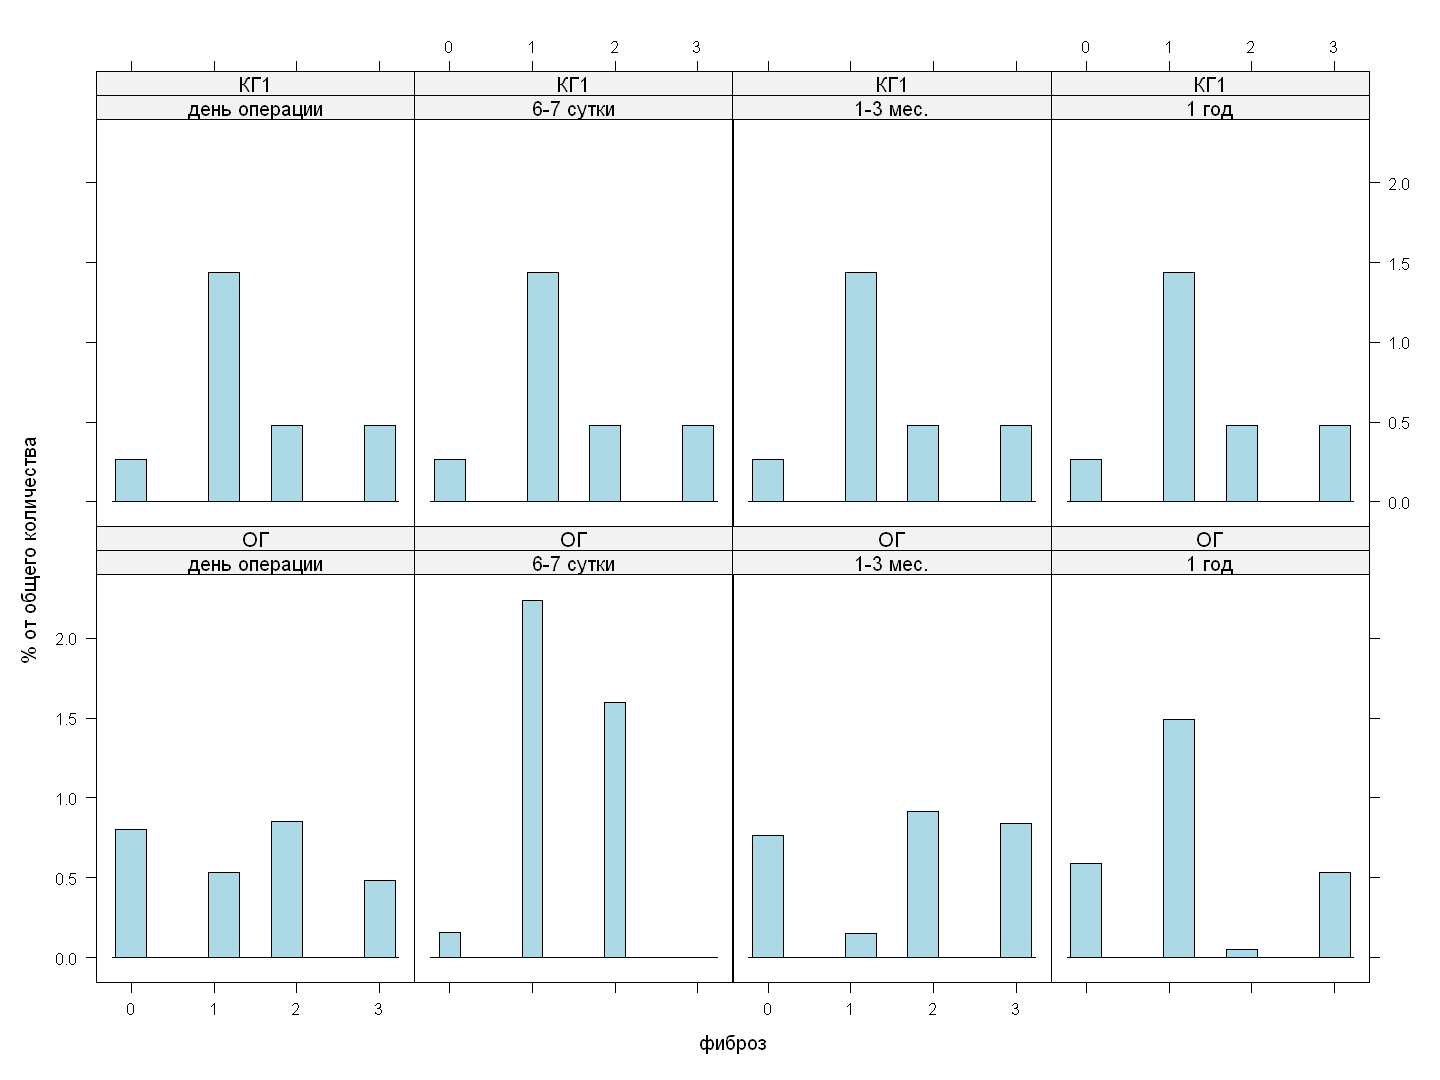

In [30]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [31]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      1.440000 0.9071147   1  0   1 1.0   2    3     50
КГ1: 1 год         1.440000 0.9071147   1  0   1 1.0   2    3     50
КГ1: 6-7 сутки     1.440000 0.9071147   1  0   1 1.0   2    3     50
КГ1: день операции 1.440000 0.9071147   1  0   1 1.0   2    3     50
ОГ: 1-3 мес.       1.685714 1.2071217   3  0   0 2.0   3    3     35
ОГ: 1 год          1.200000 1.0101525   0  0   1 1.0   1    3     50
ОГ: 6-7 сутки      1.360000 0.5686241   1  0   1 1.0   2    2     25
ОГ: день операции  1.380000 1.1045361   2  0   0 1.5   2    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,1.5,2,3,1.380000,1.1045361,50,0
КГ1.день операции,0,1,1.0,2,3,1.440000,0.9071147,50,0
ОГ.6-7 сутки,0,1,1.0,2,2,1.360000,0.5686241,25,0
КГ1.6-7 сутки,0,1,1.0,2,3,1.440000,0.9071147,50,0
ОГ.1-3 мес.,0,0,2.0,3,3,1.685714,1.2071217,35,0
КГ1.1-3 мес.,0,1,1.0,2,3,1.440000,0.9071147,50,0
ОГ.1 год,0,1,1.0,1,3,1.200000,1.0101525,50,0
КГ1.1 год,0,1,1.0,2,3,1.440000,0.9071147,50,0


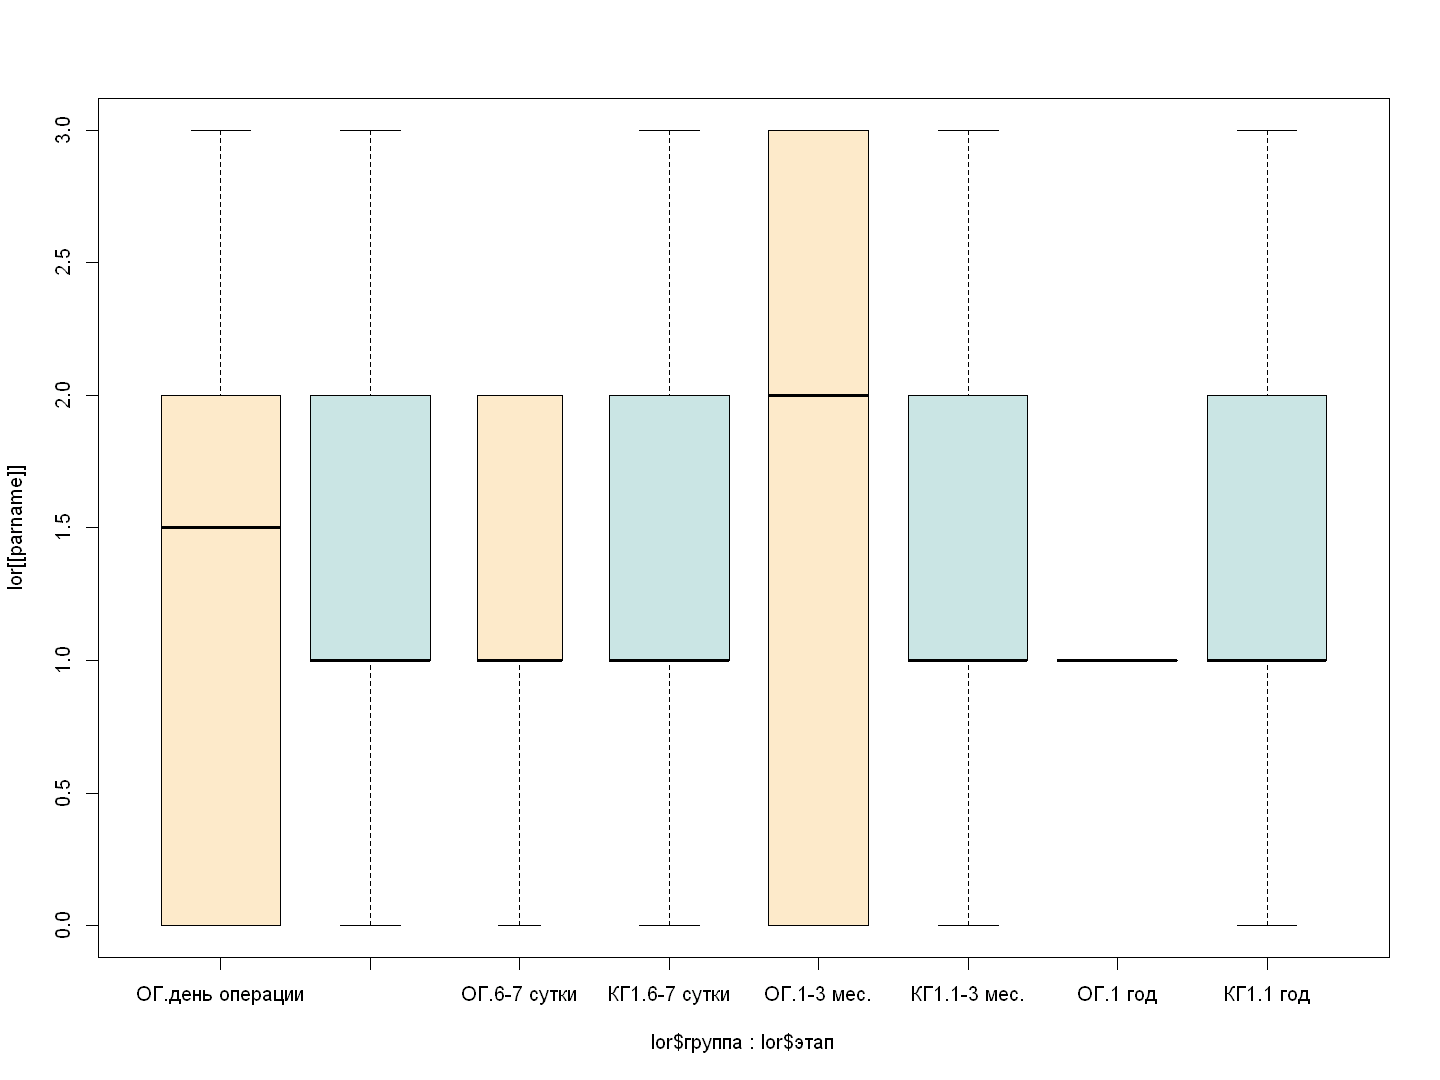

In [32]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [33]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1216, p-value = 0.8097
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -0.24437, p-value = 0.8069
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 626.5, p-value = 0.9901
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.018637, p-value = 0.9851
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1000.5, p-value = 0.2463
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 1.164, p-val

## гиперплазия респираторного эпителия

### Общее

In [34]:
parname = "гиперплазия респираторного эпителия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

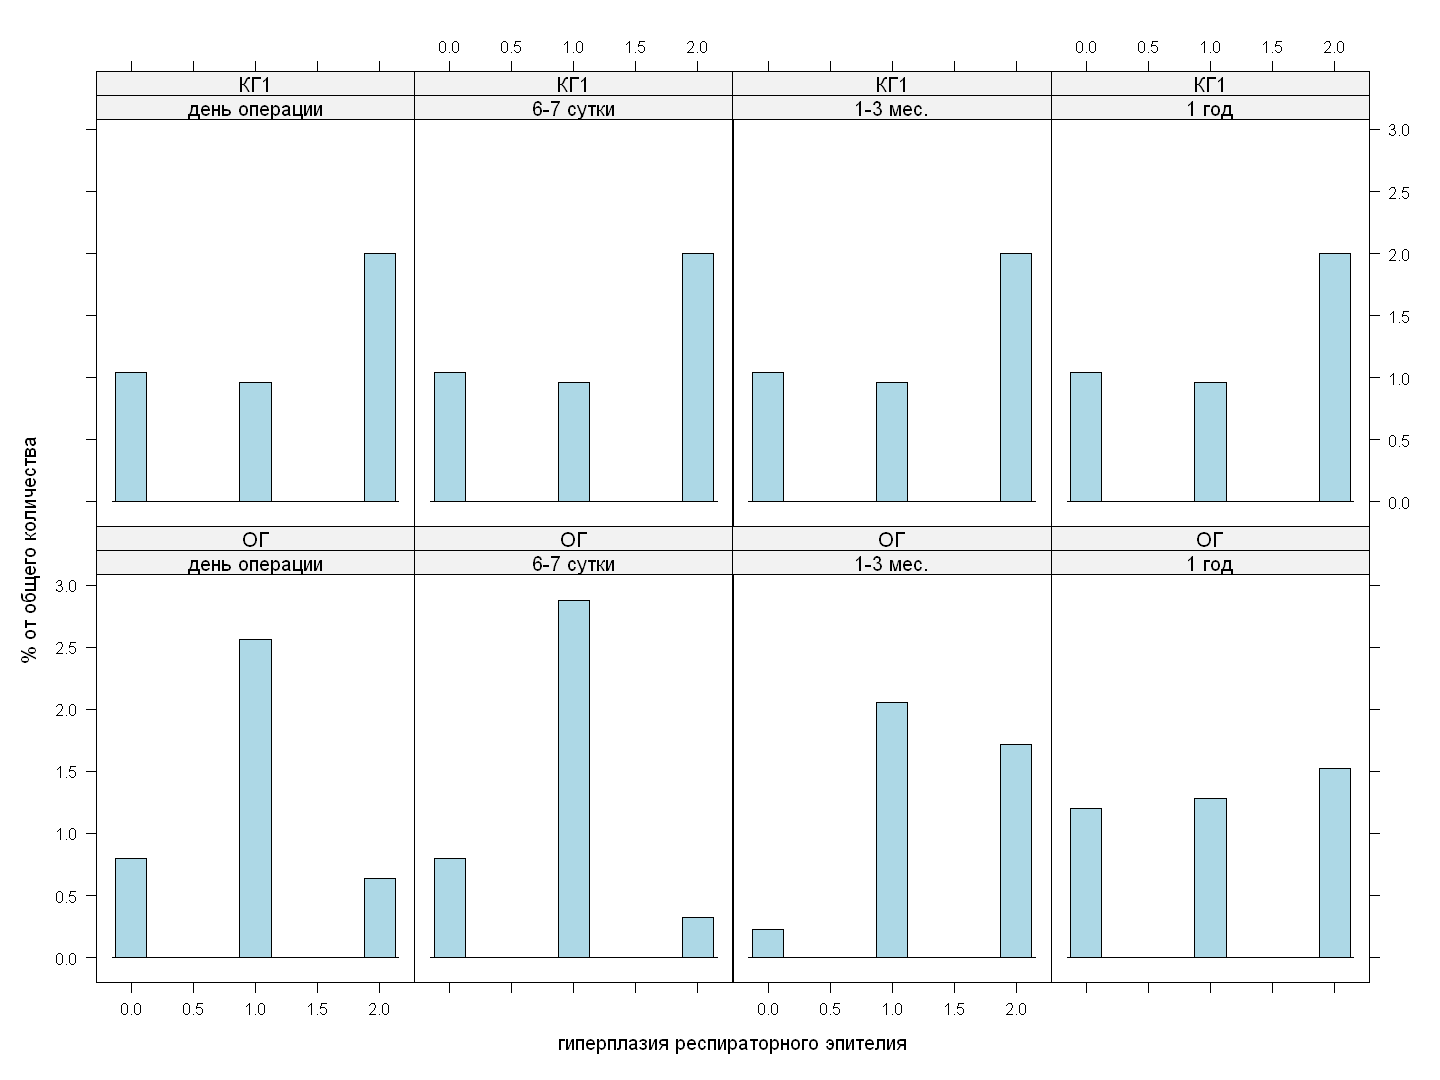

In [35]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [36]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0%  25% 50% 75% 100% data:n
КГ1: 1-3 мес.      1.240000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: 1 год         1.240000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: 6-7 сутки     1.240000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: день операции 1.240000 0.8466019 1.75  0 0.25 1.5   2    2     50
ОГ: 1-3 мес.       1.371429 0.5983170 1.00  0 1.00 1.0   2    2     35
ОГ: 1 год          1.080000 0.8290639 2.00  0 0.00 1.0   2    2     50
ОГ: 6-7 сутки      0.880000 0.5259911 0.00  0 1.00 1.0   1    2     25
ОГ: день операции  0.960000 0.6047432 0.00  0 1.00 1.0   1    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,1.00,1.0,1,2,0.960000,0.6047432,50,0
КГ1.день операции,0,0.25,1.5,2,2,1.240000,0.8466019,50,0
ОГ.6-7 сутки,0,1.00,1.0,1,2,0.880000,0.5259911,25,0
КГ1.6-7 сутки,0,0.25,1.5,2,2,1.240000,0.8466019,50,0
ОГ.1-3 мес.,0,1.00,1.0,2,2,1.371429,0.5983170,35,0
КГ1.1-3 мес.,0,0.25,1.5,2,2,1.240000,0.8466019,50,0
ОГ.1 год,0,0.00,1.0,2,2,1.080000,0.8290639,50,0
КГ1.1 год,0,0.25,1.5,2,2,1.240000,0.8466019,50,0


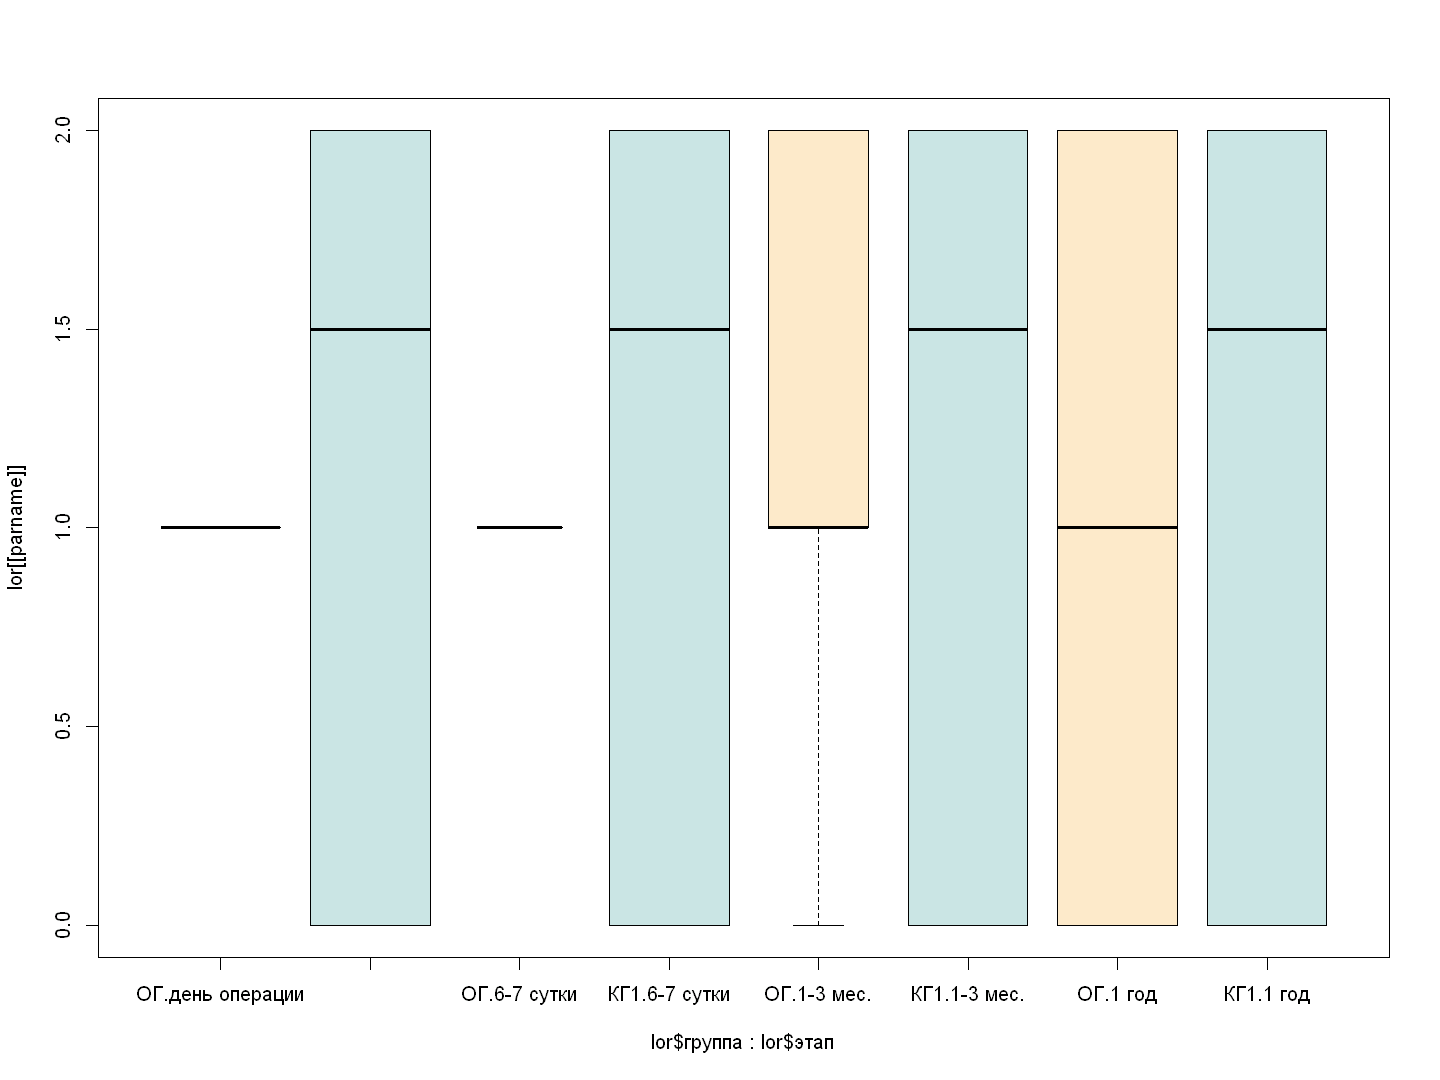

In [37]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 973, p-value = 0.04062
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -2.0511, p-value = 0.04026
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 449.5, p-value = 0.03557
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -2.1078, p-value = 0.03505
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 917.5, p-value = 0.6835
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.41249, p-v

## плоскоклеточная метаплазия

### Общее

In [39]:
parname = "плоскоклеточная метаплазия"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

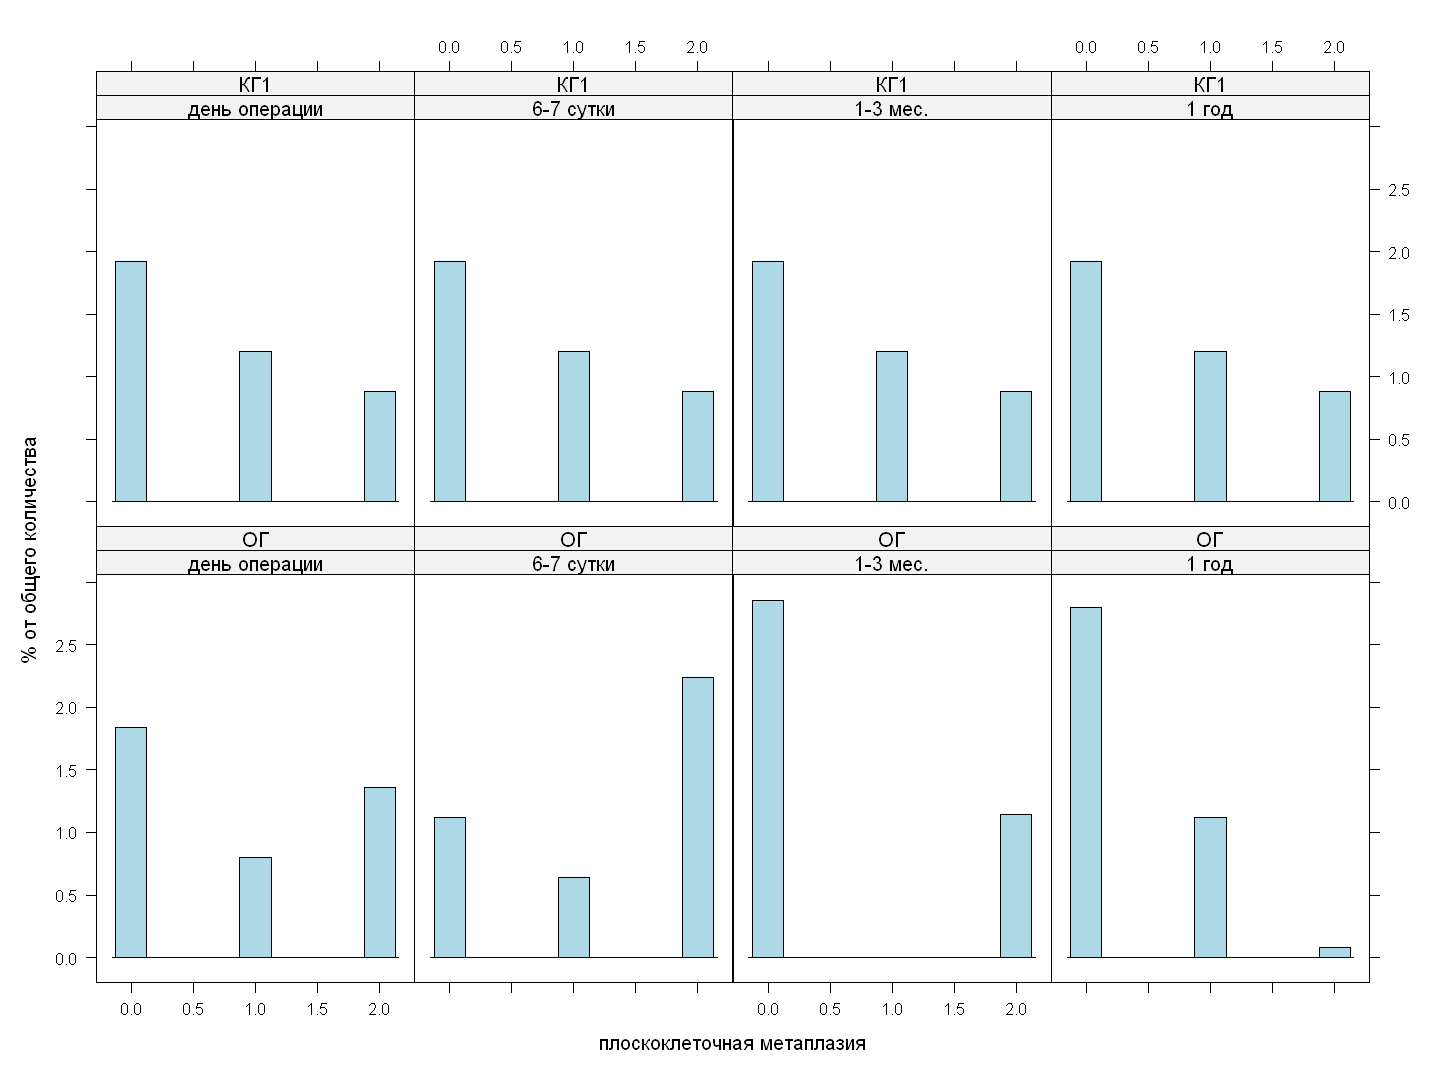

In [40]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      0.7400000 0.8033095   1  0   0   1   1    2     50
КГ1: 1 год         0.7400000 0.8033095   1  0   0   1   1    2     50
КГ1: 6-7 сутки     0.7400000 0.8033095   1  0   0   1   1    2     50
КГ1: день операции 0.7400000 0.8033095   1  0   0   1   1    2     50
ОГ: 1-3 мес.       0.5714286 0.9166985   2  0   0   0   2    2     35
ОГ: 1 год          0.3200000 0.5126960   1  0   0   0   1    2     50
ОГ: 6-7 сутки      1.2800000 0.8906926   2  0   0   2   2    2     25
ОГ: день операции  0.8800000 0.8953394   2  0   0   1   2    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,1,2,2,0.8800000,0.8953394,50,0
КГ1.день операции,0,0,1,1,2,0.7400000,0.8033095,50,0
ОГ.6-7 сутки,0,0,2,2,2,1.2800000,0.8906926,25,0
КГ1.6-7 сутки,0,0,1,1,2,0.7400000,0.8033095,50,0
ОГ.1-3 мес.,0,0,0,2,2,0.5714286,0.9166985,35,0
КГ1.1-3 мес.,0,0,1,1,2,0.7400000,0.8033095,50,0
ОГ.1 год,0,0,0,1,2,0.3200000,0.5126960,50,0
КГ1.1 год,0,0,1,1,2,0.7400000,0.8033095,50,0


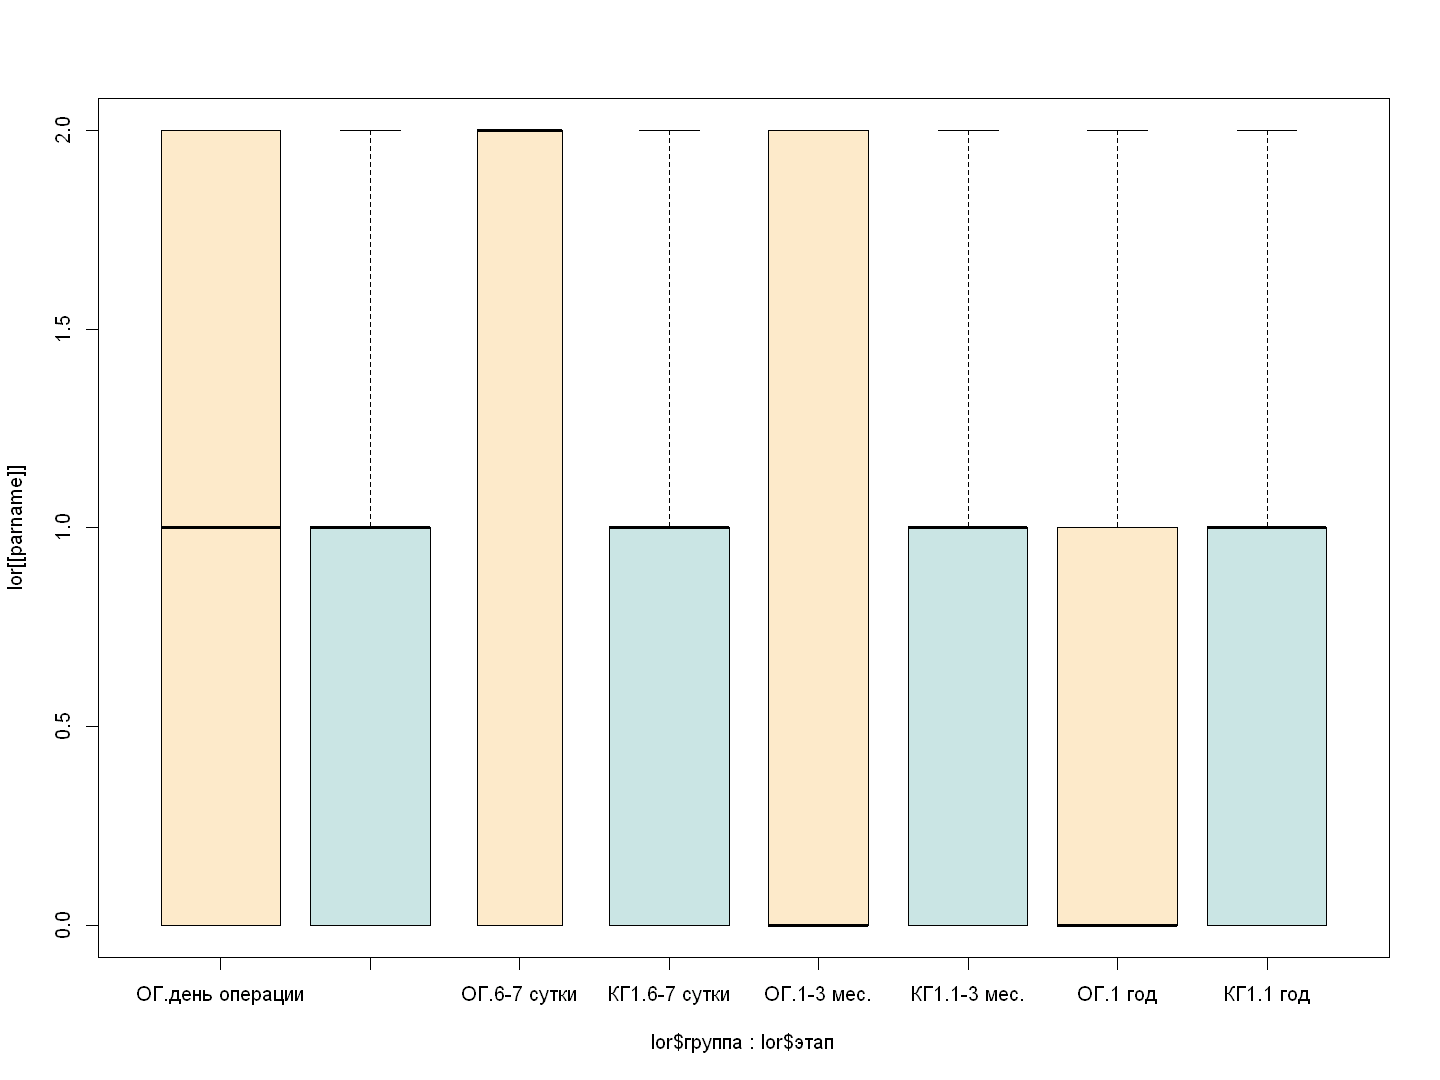

In [42]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [43]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1347.5, p-value = 0.4705
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 0.72535, p-value = 0.4682
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 833, p-value = 0.01273
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.4974, p-value = 0.01251
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 745, p-value = 0.1927
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = -1.3077, p-value

## эозинофилы

### Общее

In [44]:
parname = "эозинофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [45]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [46]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: 1 год         0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: 6-7 сутки     0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: день операции 0.0000000 0.0000000   0  0   0   0   0    0     50
ОГ: 1-3 мес.       0.3714286 0.9727376   0  0   0   0   0    3     35
ОГ: 1 год          0.0000000 0.0000000   0  0   0   0   0    0     50
ОГ: 6-7 сутки      0.6800000 0.9000000   1  0   0   0   1    3     25
ОГ: день операции  0.5000000 1.0738069   0  0   0   0   0    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0,3,0.5000000,1.0738069,50,0
КГ1.день операции,0,0,0,0,0,0.0000000,0.0000000,50,0
ОГ.6-7 сутки,0,0,0,1,3,0.6800000,0.9000000,25,0
КГ1.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,50,0
ОГ.1-3 мес.,0,0,0,0,3,0.3714286,0.9727376,35,0
КГ1.1-3 мес.,0,0,0,0,0,0.0000000,0.0000000,50,0
ОГ.1 год,0,0,0,0,0,0.0000000,0.0000000,50,0
КГ1.1 год,0,0,0,0,0,0.0000000,0.0000000,50,0


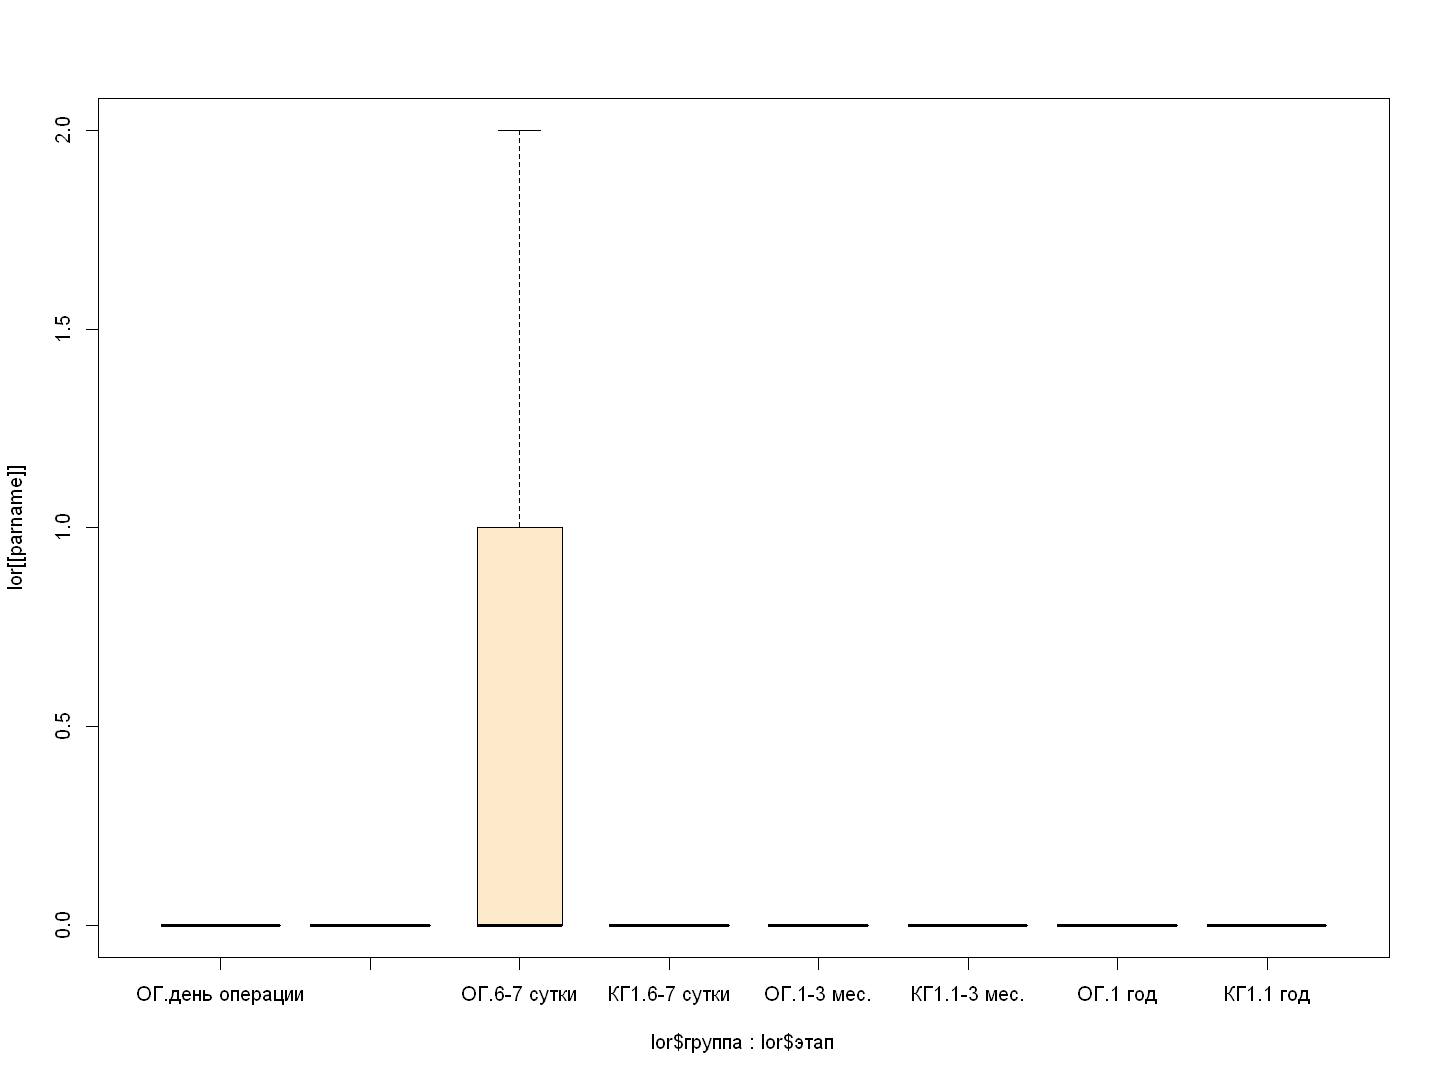

In [47]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [48]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1500, p-value = 0.0009463
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 3.3127, p-value = 0.0009242
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 925, p-value = 1.255e-07
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 5.2941, p-value = 1.196e-07
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1000, p-value = 0.006394
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.7378

## нейтрофилы

### Общее

In [49]:
parname = "нейтрофилы"
values = lor[[parname]]
parameter = lor[[groupping_variable]]

In [50]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [51]:
numSummary(values, statistics = c("mean", "sd", "IQR", "quantiles"),
           quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ': ', этап))
favstats(values ~ parameter + этап)

                         mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ1: 1-3 мес.      0.00000000 0.0000000   0  0   0   0   0    0     50
КГ1: 1 год         0.00000000 0.0000000   0  0   0   0   0    0     50
КГ1: 6-7 сутки     0.00000000 0.0000000   0  0   0   0   0    0     50
КГ1: день операции 0.00000000 0.0000000   0  0   0   0   0    0     50
ОГ: 1-3 мес.       0.02857143 0.1690309   0  0   0   0   0    1     35
ОГ: 1 год          0.00000000 0.0000000   0  0   0   0   0    0     50
ОГ: 6-7 сутки      0.88000000 0.7257180   1  0   0   1   1    3     25
ОГ: день операции  0.10000000 0.3030458   0  0   0   0   0    1     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ.день операции,0,0,0,0,1,0.10000000,0.3030458,50,0
КГ1.день операции,0,0,0,0,0,0.00000000,0.0000000,50,0
ОГ.6-7 сутки,0,0,1,1,3,0.88000000,0.7257180,25,0
КГ1.6-7 сутки,0,0,0,0,0,0.00000000,0.0000000,50,0
ОГ.1-3 мес.,0,0,0,0,1,0.02857143,0.1690309,35,0
КГ1.1-3 мес.,0,0,0,0,0,0.00000000,0.0000000,50,0
ОГ.1 год,0,0,0,0,0,0.00000000,0.0000000,50,0
КГ1.1 год,0,0,0,0,0,0.00000000,0.0000000,50,0


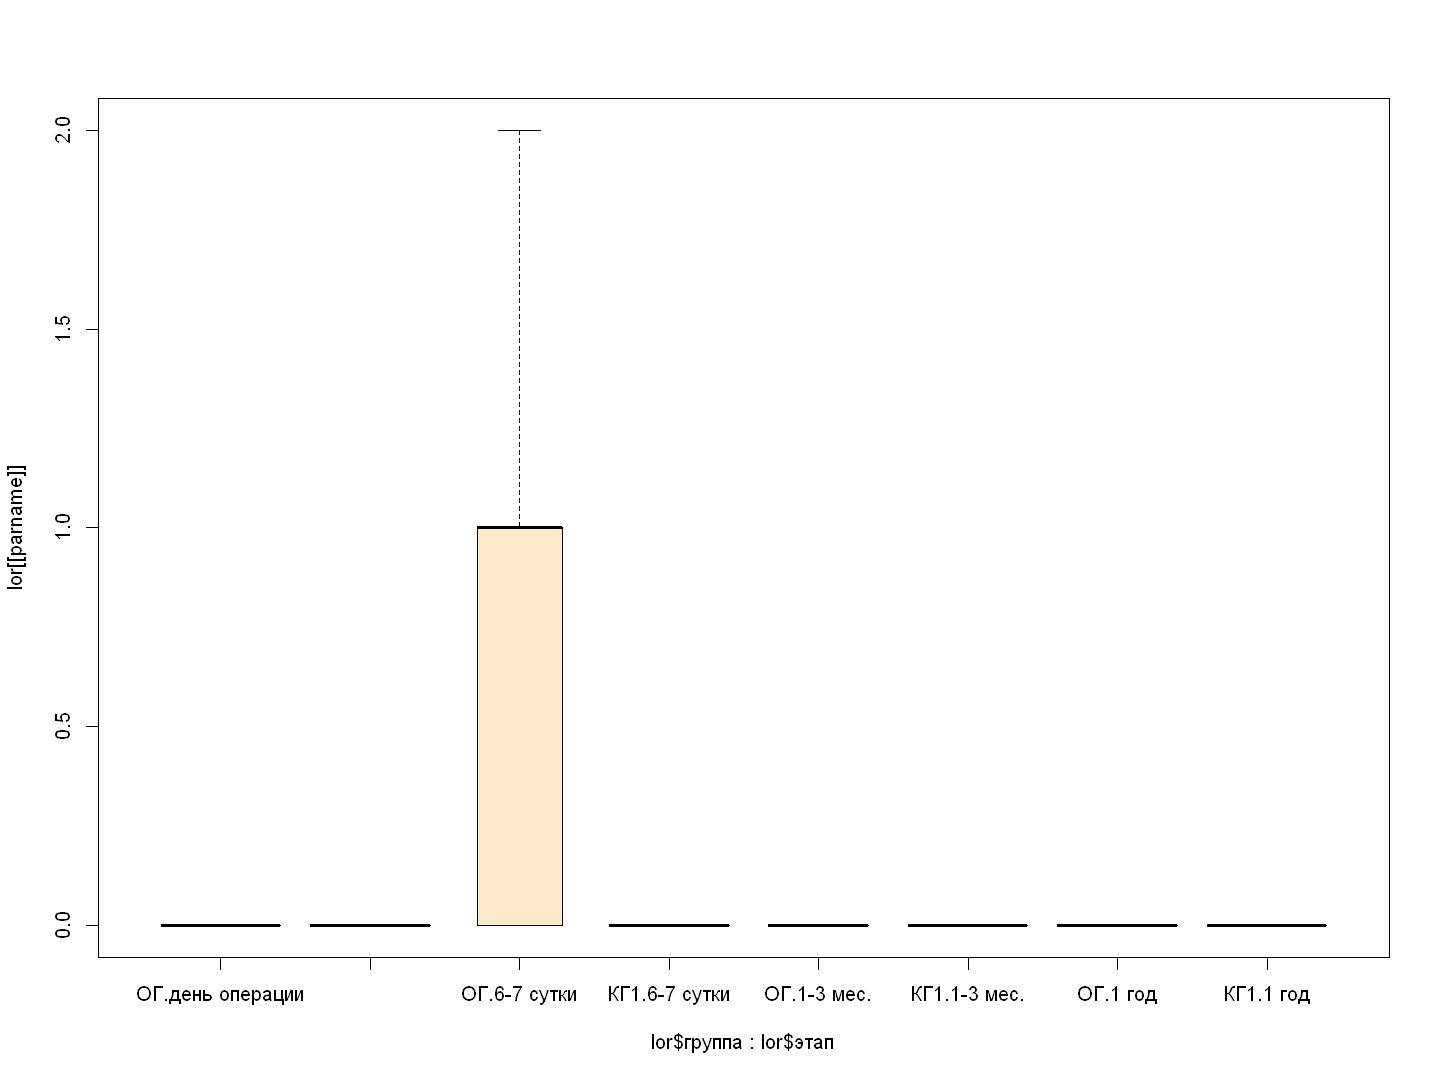

In [52]:
parname = sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1,0.6,0,0.2), rgb(0,0.5,0.5,0.2)))
#abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [53]:
for (phase in levels(этап)) {
    tmp = lor %>%
        filter(этап == phase)
    values = tmp[[parname]]
    parameter = tmp[[groupping_variable]]
    cat('================= Этап --', phase)
    if (nlevels(parameter) < 3) {
        print(wilcox.test(values ~ parameter))
        print(independence_test(values ~ parameter, data = lor,
                      alternative = "two.sided",
                      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                      xtrafo = function(data) trafo(data, ordered_trafo = ff)
                      )
              )
    } else {
        try(print(kruskal.test(values ~ parameter)))
        print(kruskalmc(values ~ parameter))
    
        cat("\n==========\nPairwise comparison \n")
        for (i in 1:(nlevels(parameter) - 1)) {
            for (j in (i + 1):nlevels(parameter)) {
                cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
                ss = subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
                try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
                print(independence_test(ss[[parname]] ~ ss[[groupping_variable]], data = ss,
                            alternative = "two.sided",
                            distribution = "exact",
                            ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
                            xtrafo = function(data) trafo(data, ordered_trafo = ff)
                            )
                      )
            }
        }
    }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1375, p-value = 0.02299
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 2.2827, p-value = 0.02245
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1075, p-value = 1.099e-11
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 6.8005, p-value = 1.043e-11
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 900, p-value = 0.2415
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (ОГ, КГ1)
Z = 1.1952, p-va